In [18]:

from icdmappings import Mapper

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
from sklearn.preprocessing import label_binarize

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, precision_recall_curve, roc_curve, roc_auc_score
)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.metrics import classification_report



In [19]:
# %% Carregar datasets já divididos
train_df = pd.read_csv("data/train.csv")
val_df   = pd.read_csv("data/val.csv")
test_df  = pd.read_csv("data/test.csv")

In [20]:

target = "TriageGrade"
mapper = Mapper()

val_df['Block'] =mapper.map(val_df['ChiefComplaint'], source='icd10', target='block')

y_test = val_df[target]


In [21]:
models_to_test = [
    "models/models/baseline_block.joblib",
    "models/models/baseline_peso_block.joblib",
    #"models/models/gb_varias.joblib",
    "models/models/rf_block.joblib",
    "models/models/rf_peso_block.joblib",
    "models/models/rf_peso_varias.joblib",
    "models/models/rf_varias.joblib",
]

In [22]:
def evaluate_model(model, X, y):
    preds = model.predict(X)
    report = classification_report(y, preds, output_dict=True, zero_division=0)

    return {
        "accuracy": accuracy_score(y, preds),
        "precision": precision_score(y, preds, average="weighted", zero_division=0),
        "recall": recall_score(y, preds, average="weighted", zero_division=0),
        "f1": f1_score(y, preds, average="weighted", zero_division=0),
        "recall_class_4": report.get('4', report.get(4, {})).get('recall', 0),
        "preds": preds
    }



In [23]:
def recall_per_class(y_true, y_pred, model_name):
    report = classification_report(y_true, y_pred, output_dict=True, zero_division=0)

    data = []
    for label in np.unique(y_true).astype(str):
        if label in report:
            data.append({
                "model": model_name,
                "class": label,
                "recall": report[label]['recall']  # Extrai o recall individual da classe [1]
            })
    return data



In [24]:
def plot_cm_normalized(y, preds, name, ax):
    # O parâmetro normalize='true' divide os valores pelo total de cada classe real (linhas)
    cm = confusion_matrix(y, preds, normalize='true')
    sns.heatmap(cm, annot=True, fmt=".2%", cmap="Blues", ax=ax)
    ax.set_title(f"Matriz de Confusão Normalizada - {name}")
    ax.set_xlabel("Previsto")
    ax.set_ylabel("Real")



In [25]:
def plot_pr_curve_class_5(y_test, probas, model_name, ax, class_label=4):
    # Binarizar para a classe específica
    classes = np.unique(y_test)
    y_bin = label_binarize(y_test, classes=classes)

    # Encontrar o índice da classe 5
    class_idx = list(classes).index(class_label)

    # Extrair probabilidades apenas para a classe 5
    precision, recall, _ = precision_recall_curve(y_bin[:, class_idx], probas[:, class_idx])

    ax.plot(recall, precision, label=f"{model_name} (Classe {class_label})")
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Curva Precision-Recall - Classe 5")
    ax.legend()



In [26]:
def plot_threshold_analysis(y_test, probas, model_name, ax, class_label=4):
    classes = np.unique(y_test)
    class_idx = list(classes).index(class_label)
    probs_class_5 = probas[:, class_idx]
    y_true_binary = (y_test == class_label).astype(int)

    thresholds = np.linspace(0, 1, 100)
    recalls = []
    precisions = []

    for th in thresholds:
        th_preds = (probs_class_5 >= th).astype(int)
        recalls.append(recall_score(y_true_binary, th_preds, zero_division=0))
        precisions.append(precision_score(y_true_binary, th_preds, zero_division=0))

    ax.plot(thresholds, recalls, label="Recall (Classe 4)")
    ax.plot(thresholds, precisions, label="Precision (Classe 4)")
    ax.axvline(0.5, color="red", linestyle="--", label="Threshold Padrão (0.5)")
    ax.set_xlabel("Limiar de Decisão (Threshold)")
    ax.set_ylabel("Score")
    ax.set_title(f"Análise de Limiar - {model_name}")
    ax.legend()
    ax.grid(True)



In [27]:
def multiclass_auc(y, probas):
    classes = np.unique(y)
    y_bin = label_binarize(y, classes=classes)

    return roc_auc_score(
        y_bin,
        probas,
        average="macro",
        multi_class="ovr"
    )



Relatório para baseline_block.joblib:
              precision    recall  f1-score   support

           1       0.23      0.54      0.33      1544
           2       0.77      0.44      0.56     12142
           3       0.40      0.31      0.35      5148
           4       0.48      0.69      0.56      2660
           5       0.00      0.00      0.00         3

    accuracy                           0.44     21497
   macro avg       0.38      0.39      0.36     21497
weighted avg       0.61      0.44      0.49     21497

Relatório para baseline_peso_block.joblib:
              precision    recall  f1-score   support

           1       0.81      0.02      0.03      1544
           2       0.85      0.33      0.47     12142
           3       0.30      0.44      0.36      5148
           4       0.26      0.90      0.41      2660
           5       0.00      0.00      0.00         3

    accuracy                           0.40     21497
   macro avg       0.44      0.34      0.25     21

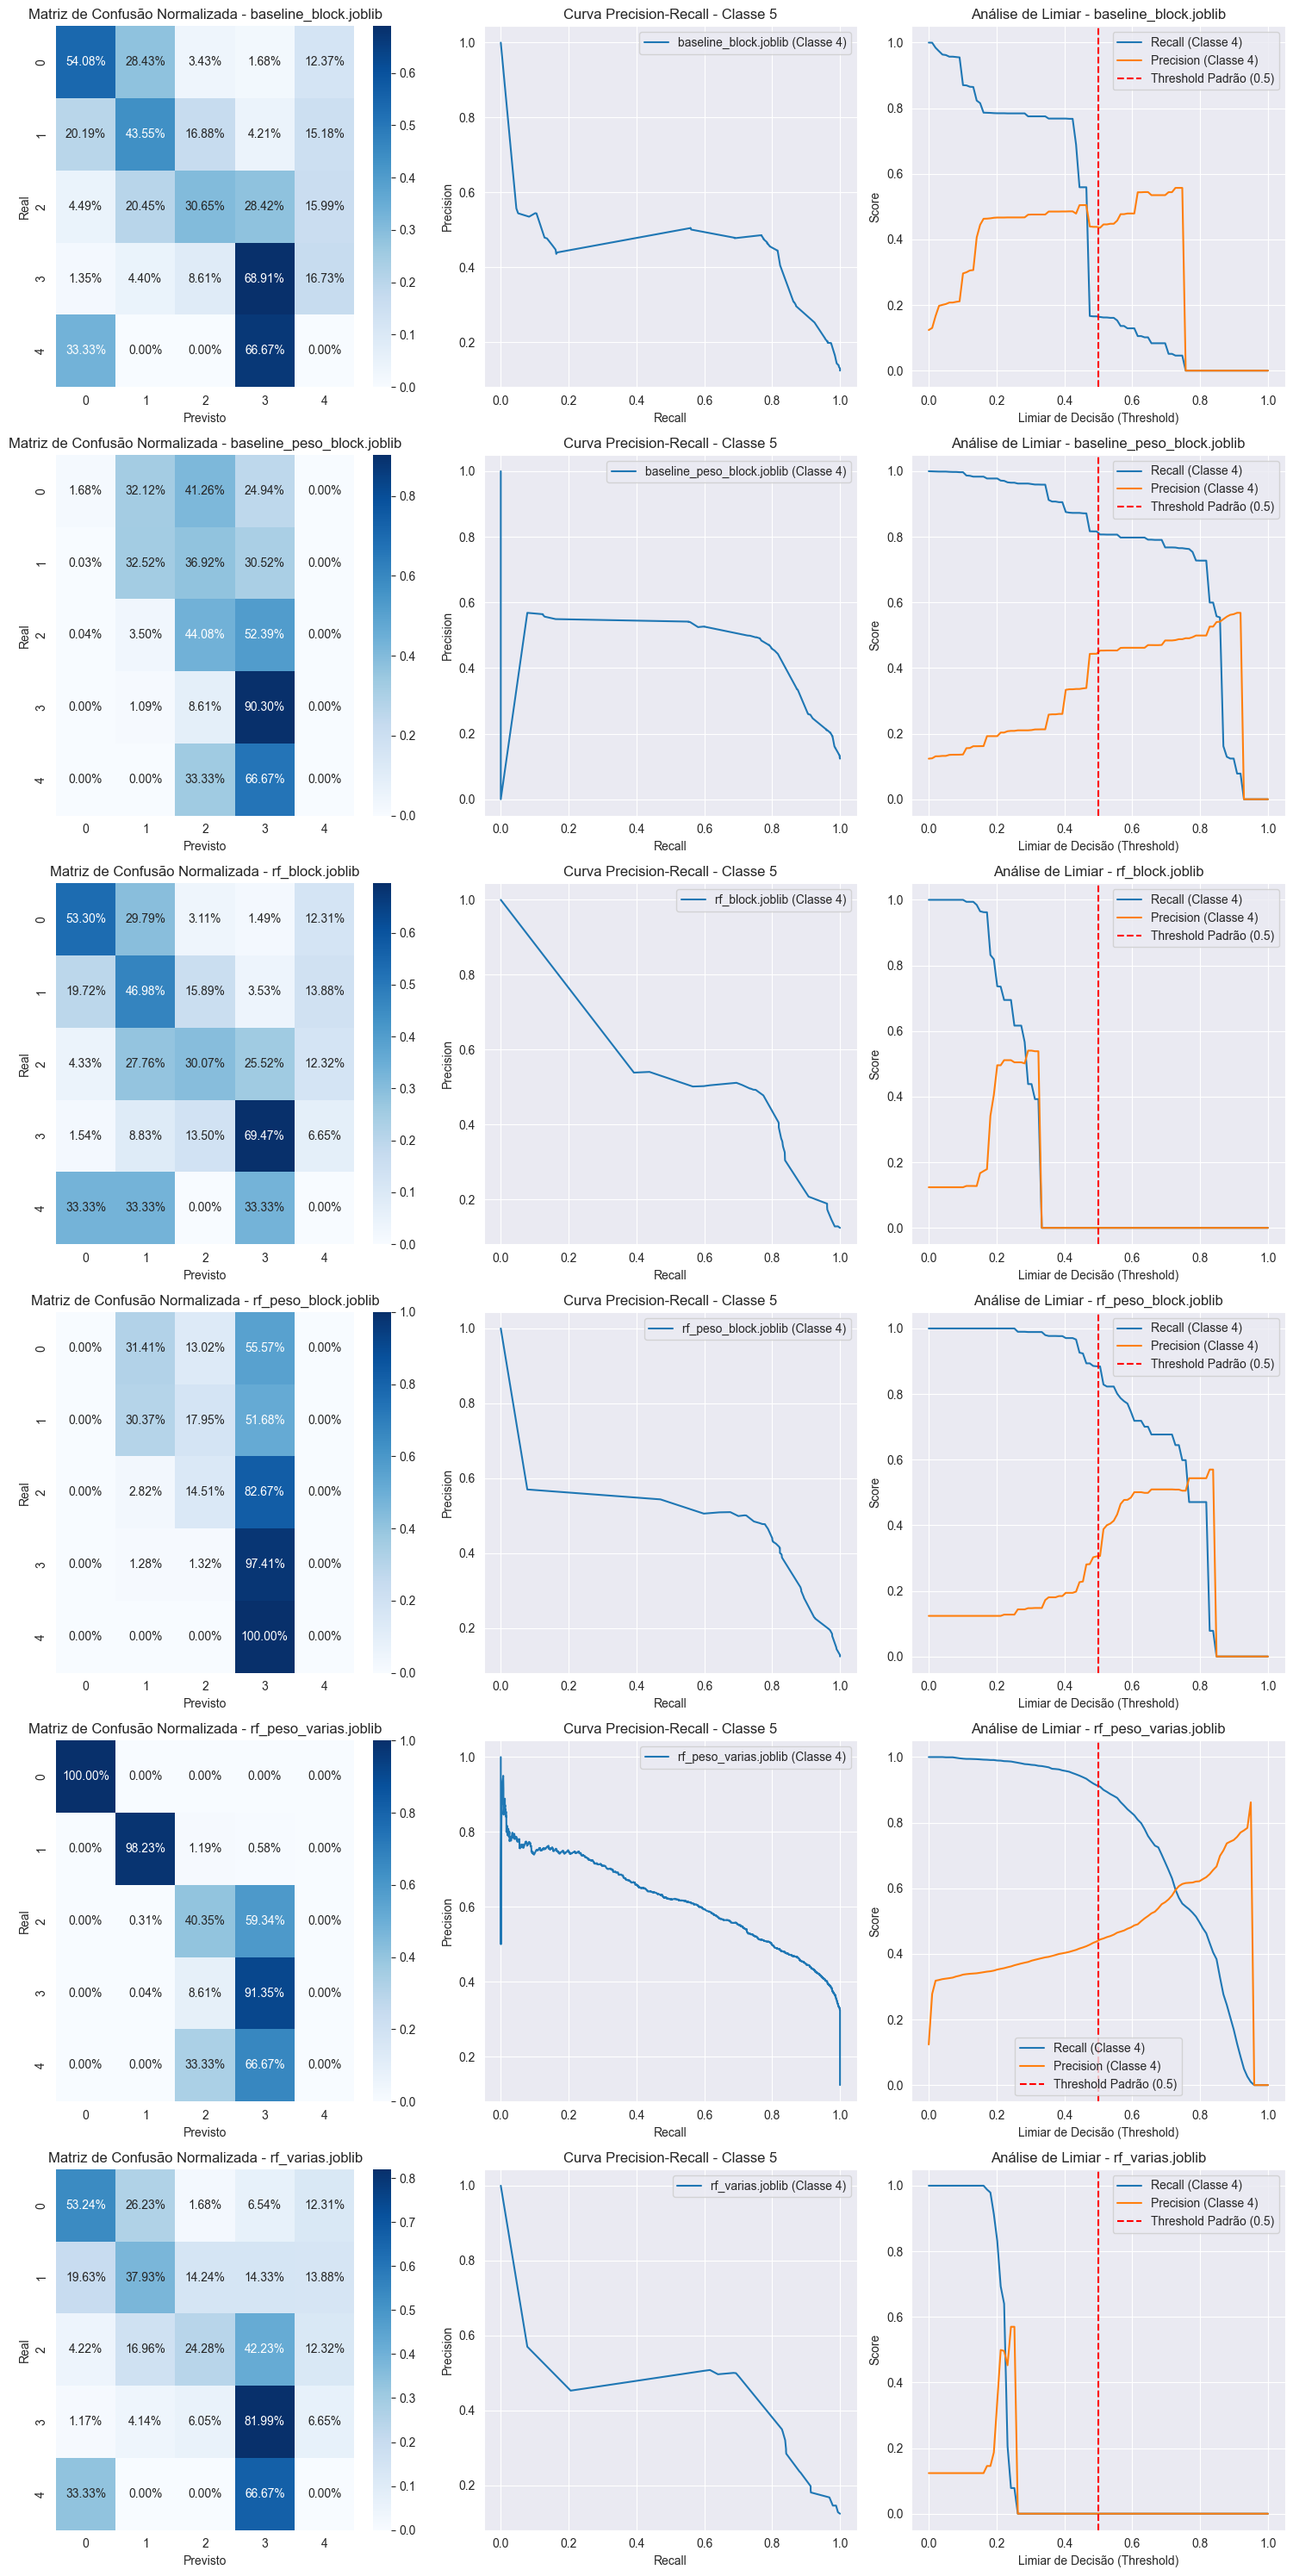

<Figure size 600x400 with 0 Axes>

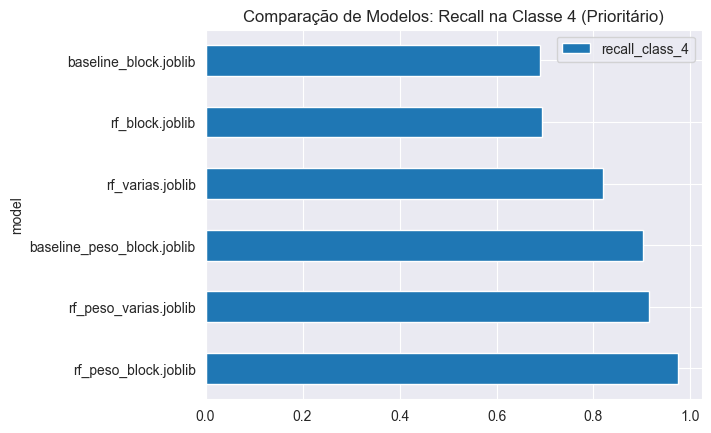

In [28]:
auc_results = []
results = []
recall_per_class_data = []  # Corrigido: Inicialização necessária [1]
f1_per_class_data = []

num_models = len(models_to_test)
cols = 3  # Número de colunas desejado

fig, axes = plt.subplots(num_models, cols, figsize=(15, 5 * num_models))

for i, path in enumerate(models_to_test):
    data = joblib.load(path)
    model = data["model"]
    features = data["features"]
    name = path.split("/")[-1]

    # Seleção de features simplificada
    X_test_model = val_df[features]  # Corrigido: Removida redundância [1]

    # Obtenção de predições e probabilidades
    preds = model.predict(X_test_model)
    probas = model.predict_proba(X_test_model)

    # Cálculo das métricas
    auc = multiclass_auc(y_test, probas)
    out = evaluate_model(model, X_test_model, y_test)

    # Relatório detalhado para extração de recall por classe
    report = classification_report(y_test, preds, output_dict=True, zero_division=0)

    # Coleta de recall individual por classe para o gráfico de barras
    for label in np.unique(y_test).astype(str):
        if label in report:
            recall_per_class_data.append({
                "model": name,
                "class": f"Classe {label}",
                "recall": report[label]['recall']  # Extrai o recall individual [7]
            })
            f1_per_class_data.append({
                "model": name,
                "class": f"Classe {label}",
                "f1_score": report[label]['f1-score']  # Extrai o f1-score individual da classe [1]
            })

    # Armazenamento dos resultados gerais
    results.append({
        "model": name,
        "accuracy": out["accuracy"],
        "precision": out["precision"],
        "recall": out["recall"],
        "f1": out["f1"],
        "recall_class_4": out["recall_class_4"]  # Métrica prioritária [7]
    })

    auc_results.append({
        "model": name,
        "auc_macro_ovr": auc
    })

    # Visualização imediata por modelo
    plot_cm_normalized(y_test, preds, name, ax=axes[i, 0])
    plot_pr_curve_class_5(y_test, probas, name, ax=axes[i, 1], class_label=4)
    plot_threshold_analysis(y_test, probas, name, ax=axes[i, 2], class_label=4)

    print(f"Relatório para {name}:")
    print(classification_report(y_test, preds, zero_division=0))
plt.tight_layout()
plt.show()

# Criação dos DataFrames finais após o loop

df_recalls_all = pd.DataFrame(recall_per_class_data)
df_f1_all = pd.DataFrame(f1_per_class_data)

df_comp = pd.DataFrame(results)

plt.figure(figsize=(6, 4))
df_comp.sort_values("recall_class_4", ascending=False).plot(x="model", y="recall_class_4", kind="barh")
plt.title("Comparação de Modelos: Recall na Classe 4 (Prioritário)")
plt.show()


In [29]:
df_results = pd.DataFrame(results)
df_results.sort_values("recall_class_4", ascending=False)


,model,accuracy,precision,recall,f1,recall_class_4
3,rf_peso_block.joblib,0.326790,0.558111,0.326790,0.334108,0.974060
4,rf_peso_varias.joblib,0.836303,0.892876,0.836303,0.835293,0.913534
1,baseline_peso_block.joblib,0.402196,0.641271,0.402196,0.403243,0.903008
5,rf_varias.joblib,0.412057,0.589193,0.412057,0.443418,0.819925
2,rf_block.joblib,0.461599,0.587186,0.461599,0.501130,0.694737
0,baseline_block.joblib,0.443504,0.605745,0.443504,0.490572,0.689098


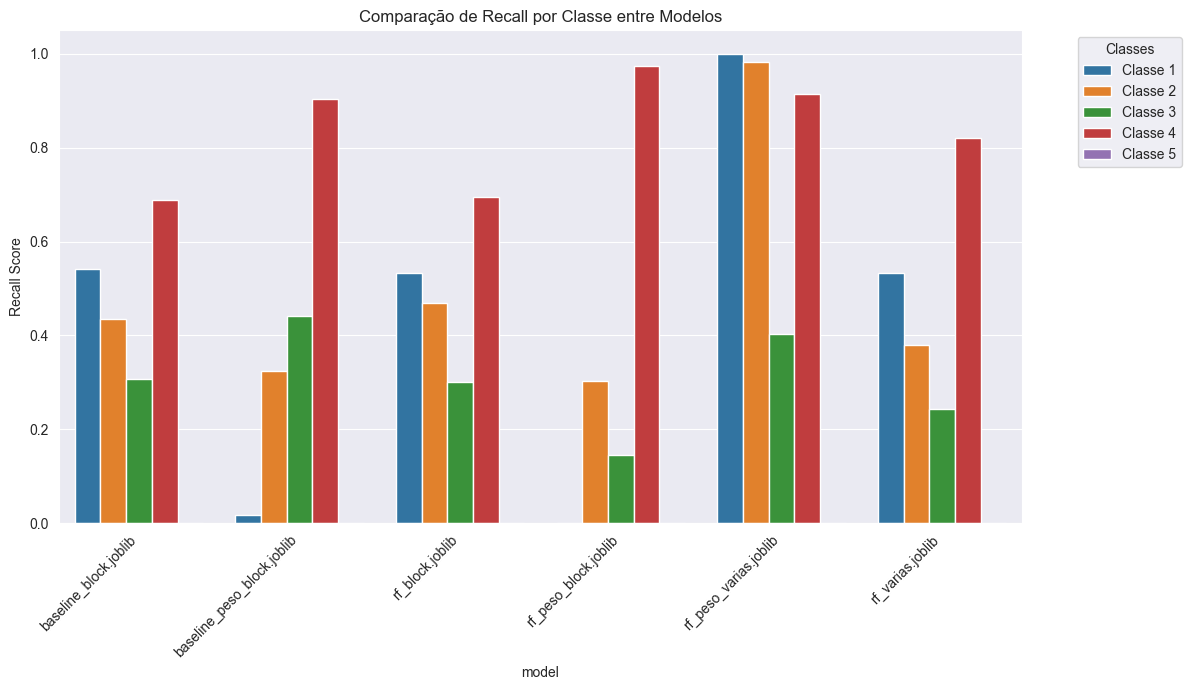

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))
sns.barplot(data=df_recalls_all, x='model', y='recall', hue='class')
plt.title("Comparação de Recall por Classe entre Modelos")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Recall Score")
plt.legend(title="Classes", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


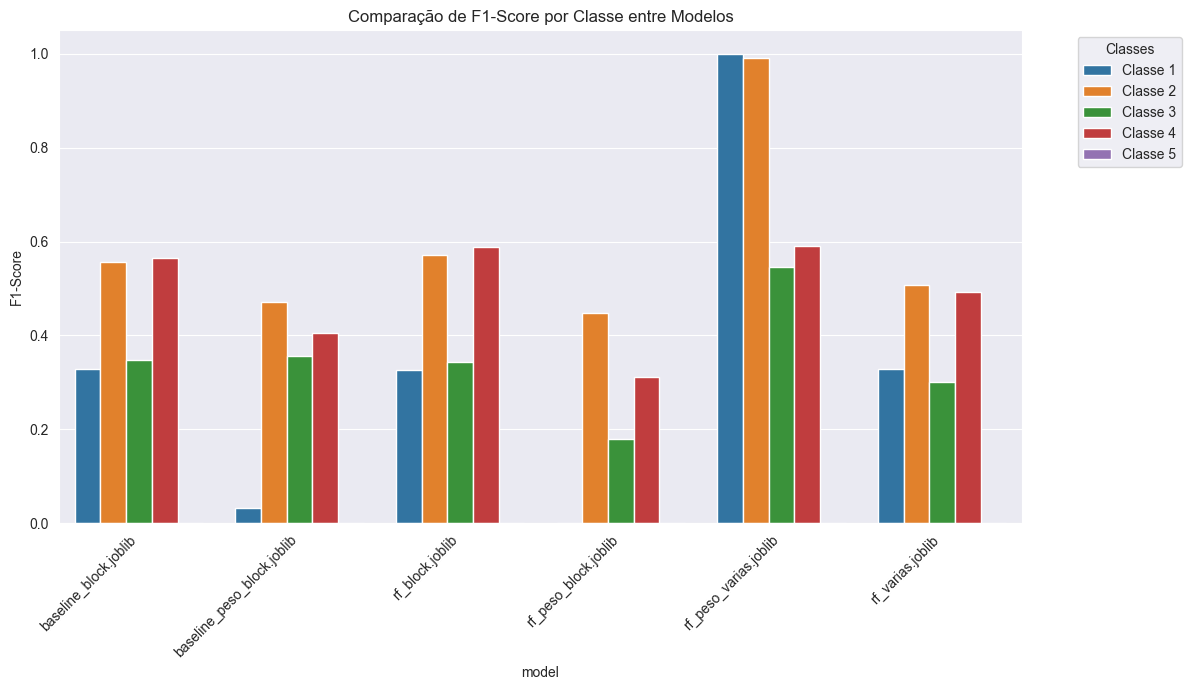

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))
# Note o uso de 'f1_score' no eixo Y
sns.barplot(data=df_f1_all, x='model', y='f1_score', hue='class')

plt.title("Comparação de F1-Score por Classe entre Modelos")
plt.xticks(rotation=45, ha='right')
plt.ylabel("F1-Score")
plt.legend(title="Classes", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()